## Вращение на орбите 2D

Выполнила: Зыкова Полина, студентка 626 группы

**Аннотация**

Данная работа посвящена численному моделированию орбитального движения в задаче двух тел. Исследуется движение трех планет — Земли, Марса и Юпитера — в гравитационном поле Солнца. Для описания их орбит используются как аналитическое решение, так и пять численных методов: явный метод Эйлера, метод Рунге-Кутты 4-го порядка, метод Верлета, а также явный и неявный методы Адамса второго порядка.

Проведено сравнение методов по трем ключевым критериям: точность воспроизведения орбитальной траектории, сохранение полной механической энергии и сохранение углового момента. Моделирование выполнялось на интервале в 25 орбитальных периодов.

Показано, что на рассматриваемом интервале метод Рунге-Кутты 4-го порядка демонстрирует наивысшую точность по сохранению энергии, превосходя по этому показателю симплектический метод Верлета. При этом метод Верлета проявляет свойства долговременной стабильности, сохраняя энергию в узком диапазоне колебаний.

**Ключевые слова**

Орбитальное движение, эллипс, метод Эйлера, метод Рунге-Кутты, методы Адамса, метод Верлета.

**1. Введение**

История исследования орбитального движения небесных тел насчитывает около двух тысячелетий. Клавдий Птолемей во II веке н.э. разработал геоцентрическую систему мира с эпициклами [1], которая оставалась основной космологической моделью до XVI века. Николай Коперник в труде "О вращении небесных сфер" (1543) предложил гелиоцентрическую систему [2], однако математическое описание орбит оставалось сложным. Иоганн Кеплер в начале XVII века, анализируя наблюдения Тихо Браге, сформулировал три закона движения планет [3], установив, что орбиты имеют форму эллипсов. Исаак Ньютон в "Математических началах натуральной философии" (1687) дал строгое математическое обоснование этих законов через закон всемирного тяготения [4].

Развитие численных методов для решения дифференциальных уравнений началось в XVIII веке. Леонард Эйлер предложил простейший метод численного интегрирования [5], который стал основой для многих последующих разработок. В конце XIX века Карл Рунге и Мартин Вильгельм Кутта разработали семейство методов повышенной точности [6], [7]. Кроме того, в XIX веке значительный вклад в развитие многошаговых методов внесли Джон Кауч Адамс и Ф. Башфорт, разработавшие методы прогноза и коррекции [8]. Также в конце XIX века был предложен метод Адамса-Моултона, сочетающий явную схему Башфорта и неявную коррекцию. Лу Верле в 1967 году разработал симплектический алгоритм [9], особенно эффективный для долговременного моделирования гамильтоновых систем.

В данной работе выполнено численное моделирование орбитального движения трех планет Солнечной системы (Земли, Марса и Юпитера) с использованием пяти различных методов: Эйлера, Рунге-Кутты 4-го порядка, Верлета, Адамса-Бэшфорта и Адамса-Моултона. Проведено сравнительное исследование точности методов по трем ключевым параметрам: отклонение от аналитической траектории, сохранение полной механической энергии и сохранение момента импульса на интервале 25 орбитальных периодов. Показано, что метод Рунге-Кутты 4-го порядка демонстрирует наивысшую точность на конечных интервалах моделирования, в то время как алгоритм Верлета обеспечивает наилучшую долговременную стабильность сохранения энергии.

**2. Среда программирования**

Для решения задачи вращения на орбите 2D будем использовать язык Python. Подключаем необходимые библиотеки:

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

**3. Математическая постановка задачи орбитального движения в гравитационном поле** 

В рамках работы будет рассматриваться орбитальное движение трех планет: Земли, Марса и Юпитера. Для этого необходимо знать большую полуось, эксцентриситет орбиты, орбитальный период и массу для каждой из планет, а также массу Солнца.

Для простоты вычислений перейдем в систему единиц, где единица длины - это одна астрономическая единица, единица времени - это один земной год, единица массы - это масса Земли. 

Часть кода, отвечающая за используемые константы:

In [5]:
a_Earth = 1.0 # большая полуось в а.е.
e_Earth = 0.017 # эксцентриситет орбиты
T_Earth = 1 # орбитальный период в земных годах
m_Earth = 1 # масса

a_Mars = 1.524
e_Mars = 0.094
T_Mars = 1.881
m_Mars = 0.107

a_Jupiter = 5.204
e_Jupiter = 0.049
T_Jupiter = 11.862
m_Jupiter = 317.8

m_Sun = 332946

Орбитальное движение в гравитационном поле описывается следующей системой дифференциальных уравнений:

\begin{cases}
\frac{dx}{dt} = v_x \\
\frac{dy}{dt} = v_y \\
\frac{dv_x}{dt} = -\frac{GM \cdot x}{r^3} \\
\frac{dv_y}{dt} = -\frac{GM \cdot y}{r^3}
\end{cases}

$$
r = \sqrt{x^2 + y^2}
$$

В коде эта система описывается следующей функцией:

In [6]:
# гравитационный параметр GM = G * M_sun
def GM(a, T):
    return 4 * np.pi**2 * a**3 / T**2 
    
def d(s, a, T):
    x, y, vx, vy = s
    r = math.sqrt(x**2 + y**2)
    return np.array([vx, vy, - GM(a, T) * x / r**3, - GM(a, T) * y / r**3])

Данная задача имеет аналитическое решение:

\begin{cases}
r(\theta) = \dfrac{a(1 - e^2)}{1 + e \cos\theta} \\
x(\theta) = r(\theta) \cos\theta \\
y(\theta) = r(\theta) \sin\theta
\end{cases}

В коде это решение реализуется следующей функцией:

In [7]:
def analytic_solution(a, e):
    theta = np.linspace(0, 2*np.pi, 1000)
    r = a * (1 - e**2) / (1 + e * np.cos(theta))
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

Как выглядит аналитические орбиты для Земли, Марса и Юпитера:

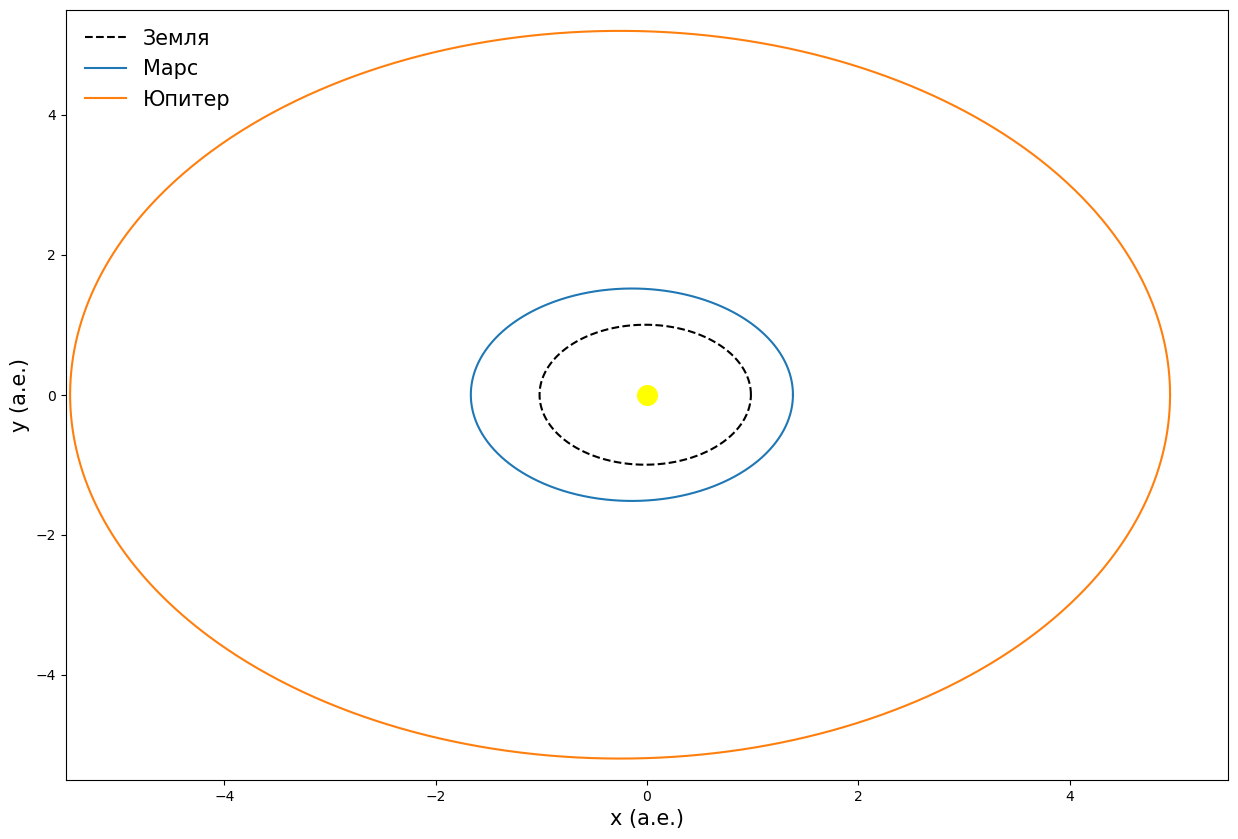

In [8]:
x_an_E, y_an_E = analytic_solution(a_Earth, e_Earth)
x_an_M, y_an_M = analytic_solution(a_Mars, e_Mars)
x_an_J, y_an_J = analytic_solution(a_Jupiter, e_Jupiter)

fig = plt.figure(figsize=(15, 10))
plt.plot(x_an_E, y_an_E, 'k--', label='Земля')
plt.plot(x_an_M, y_an_M, label='Марс')
plt.plot(x_an_J, y_an_J, label='Юпитер')
plt.scatter([0], [0], c='yellow', s=200)
plt.xlabel('x (а.е.)', fontsize=15)
plt.ylabel('y (а.е.)', fontsize=15)
plt.legend(loc='upper left', frameon=False, fontsize=15)
plt.xlim(-5.5, 5.5)
plt.ylim(-5.5, 5.5)
plt.show()

Начальные условия для каждой планеты:

$$
x_0 = (1-e)a, \quad y_0 = 0
$$

$$
v_{x0} = 0, \quad v_{y0} = \sqrt{\frac{GM(1 + e)}{a(1 - e)}}
$$

In [9]:
def init_cond(a, e, T):
    x0, y0 = (1-e)*a, 0
    vx0, vy0 = 0, math.sqrt(GM(a, T) * (1+e) / (a * (1-e)))
    return x0, y0, vx0, vy0

**4. Численное решение**

**•** *Метод Эйлера*

Разностная схема:

\begin{cases}
x^{i+1} = x^i + v_x^i \cdot \Delta t \\
y^{i+1} = y^i + v_y^i \cdot \Delta t \\
v_x^{i+1} = v_x^i \\
v_y^{i+1} = v_y^i - g \cdot \Delta t
\end{cases}

Участок кода, реализуюший ее:

In [10]:
def explicit_euler_step(s, dt, a, T):
    d1 = dt * d(s, a, T)
    return s + d1

**•** *Метод Рунге-Кутты*

Разностная схема:

\begin{cases}
x^{i+1} &= x^i + \frac{\Delta t}{6}(k_{x1} + 2k_{x2} + 2k_{x3} + k_{x4}) \\
y^{i+1} &= y^i + \frac{\Delta t}{6}(k_{y1} + 2k_{y2} + 2k_{y3} + k_{y4}) \\
v_x^{i+1} &= v_x^i + \frac{\Delta t}{6}(k_{v_{x1}} + 2k_{v_{x2}} + 2k_{v_{x3}} + k_{v_{x4}}) \\
v_y^{i+1} &= v_y^i + \frac{\Delta t}{6}(k_{v_{y1}} + 2k_{v_{y2}} + 2k_{v_{y3}} + k_{v_{y4}}) \\
\end{cases}

$$
k_{x1} = v_x^i, \quad k_{y1} = v_y^i, \quad k_{v_{x1}} = -\frac{GM \cdot {x^i}}{r^3}, \quad k_{v_{y1}} = -\frac{GM \cdot {y^i}}{r^3}  
$$

$$
r = \sqrt{{x^i}^2 + {y^i}^2}
$$

$$
k_{x2} = v_x^i + \frac{\Delta t}{2} \cdot k_{v_{x1}}, \quad k_{y2} = v_y^i + \frac{\Delta t}{2} \cdot k_{v_{y1}}, \quad k_{v_{x2}} = -\frac{GM \cdot \left(x^i + \frac{\Delta t}{2} \cdot k_{x1}\right)}{r_2^3}, \quad k_{v_{y2}} = -\frac{GM \cdot \left(y^i + \frac{\Delta t}{2} \cdot k_{y1}\right)}{r_2^3}
$$

$$
r_2 = \sqrt{\left(x^i + \frac{\Delta t}{2}k_{x1}\right)^2 + \left(y^i + \frac{\Delta t}{2}k_{y1}\right)^2}
$$

$$
k_{x3} = v_x^i + \frac{\Delta t}{2} \cdot k_{v_{x2}}, \quad k_{y3} = v_y^i + \frac{\Delta t}{2} \cdot k_{v_{y2}}, \quad k_{v_{x3}} = -\frac{GM \cdot \left(x^i + \frac{\Delta t}{2} \cdot k_{x2}\right)}{r_3^3}, \quad k_{v_{y3}} = -\frac{GM \cdot \left(y^i + \frac{\Delta t}{2} \cdot k_{y2}\right)}{r_3^3}
$$

$$
r_3 = \sqrt{\left(x^i + \frac{\Delta t}{2}k_{x2}\right)^2 + \left(y^i + \frac{\Delta t}{2}k_{y2}\right)^2}
$$

$$
k_{x4} = v_x^i + \Delta t \cdot k_{v_{x3}}, \quad k_{y4} = v_y^i + \Delta t \cdot k_{v_{y3}}, \quad k_{v_{x4}} = -\frac{GM \cdot \left(x^i + \Delta t \cdot k_{x3}\right)}{r_4^3}, \quad k_{v_{y4}} = -\frac{GM \cdot \left(y^i + \Delta t \cdot k_{y3}\right)}{r_4^3}
$$

$$
r_4 = \sqrt{\left(x^i + \Delta t \cdot k_{x3}\right)^2 + \left(y^i + \Delta t \cdot k_{y3}\right)^2}
$$

Участок кода, реализующий ее:

In [11]:
def rk4_step(s, dt, a, T):
    d1 = dt * d(s, a, T)
    d2 = dt * d(s + d1 / 2, a, T)
    d3 = dt * d(s + d2 / 2, a, T)
    d4 = dt * d(s + d3, a, T)
    return s + (d1 + 2 * d2 + 2 * d3 + d4) / 6

**•** *Метод Верлета*

Разностная аппроксимация для координат (положения на целых шагах):

\begin{aligned}
\frac{x_{n+1} - x_n}{\Delta t} &= v_{x_{n+1/2}} \\
\frac{y_{n+1} - y_n}{\Delta t} &= v_{y_{n+1/2}}
\end{aligned}

Разностная аппроксимация для скоростей (скорость на половинных шагах):

\begin{aligned}
\frac{v_{x_{n+1/2}} - v_{x_{n-1/2}}}{\Delta t} &= a_{x_n} = -\frac{GM \cdot x_n}{r_n^3} \\
\frac{v_{y_{n+1/2}} - v_{y_{n-1/2}}}{\Delta t} &= a_{y_n} = -\frac{GM \cdot y_n}{r_n^3}
\end{aligned}

$$
r_n = \sqrt{x_n^2 + y_n^2}
$$

Отсюда получим уравнения для координат:

\begin{aligned}
x_{n+1} &= x_n + \Delta t \cdot v_{x_{n+1/2}} \\
y_{n+1} &= y_n + \Delta t \cdot v_{y_{n+1/2}}
\end{aligned}

И уравнения для скоростей:

\begin{aligned}
v_{x_{n+1/2}} &= v_{x_{n-1/2}} + \Delta t \cdot \left(-\frac{GM \cdot x_n}{r_n^3}\right) \\
v_{y_{n+1/2}} &= v_{y_{n-1/2}} + \Delta t \cdot \left(-\frac{GM \cdot y_n}{r_n^3}\right)
\end{aligned}

Разберем пошагово работу алгоритма. На нулевом шаге $x_0$ и $y_0$ присваиваются начальные координаты тела.

\begin{aligned}
x_0 = x(t_0) \\
y_0 = y(t_0) \\
r_0 = \sqrt{x_0^2 + y_0^2}
\end{aligned}

Далее скорости вычисляются следующим образом:

\begin{aligned}
v_{x_{1/2}} = v_x(t_0) + \frac{\Delta t}{2} \cdot \left(-\frac{GM \cdot x_0}{r_0^3}\right) \\
v_{y_{1/2}} = v_y(t_0) + \frac{\Delta t}{2} \cdot \left(-\frac{GM \cdot y_0}{r_0^3}\right)
\end{aligned}

Далее для каждого шага n = 1, 2, 3, ... сначала обновляем координаты:

\begin{aligned}
x_{n+1} &= x_n + \Delta t \cdot v_{x_{n+1/2}} \\
y_{n+1} &= y_n + \Delta t \cdot v_{y_{n+1/2}} \\
r_{n+1} &= \sqrt{x_{n+1}^2 + y_{n+1}^2}
\end{aligned}

Затем обновляем скорости:

\begin{aligned}
v_{x_{n+3/2}} &= v_{x_{n+1/2}} + \Delta t \cdot \left(-\frac{GM \cdot x_{n+1}}{r_{n+1}^3}\right) \\
v_{y_{n+3/2}} &= v_{y_{n+1/2}} + \Delta t \cdot \left(-\frac{GM \cdot y_{n+1}}{r_{n+1}^3}\right)
\end{aligned}

Участок кода, реализующий данную схему:

In [12]:
# Y_n - вектор положения на шаге n [x_n, y_n]
# V_half - вектор скорости на шаге n+1/2 [vx_{n+1/2}, vy_{n+1/2}]
# Возвращает:
# Y_{n+1} - положение на шаге n+1
# V_{n+3/2} - скорость на шаге n+3/2
def verlet_step(Y_n, V_half, dt, a, T):
    # Обновление координат
    Y_next = Y_n + dt * V_half
    
    # Вычисление ускорения в новой точке
    r = math.sqrt(Y_next[0]**2 + Y_next[1]**2)
    A_next = np.array([-GM(a, T) * Y_next[0] / r**3, -GM(a, T) * Y_next[1] / r**3])
    
    # Обновление скоростей
    V_next_half = V_half + dt * A_next
    
    return Y_next, V_next_half

def verlet_integration(x0, y0, vx0, vy0, dt, N, a, T):

    # Положения
    Y = np.zeros((N + 1, 2)) 
    Y[0] = np.array([x0, y0])
    
    # Скорости на половинных шагах
    V_half = np.zeros((N + 1, 2))  
    r0 = math.sqrt(x0**2 + y0**2)
    A0 = np.array([-GM(a, T) * x0 / r0**3, -GM(a, T) * y0 / r0**3])
    V_half[0] = np.array([vx0, vy0]) + 0.5 * dt * A0
    
    for n in range(N):
        Y[n+1], V_half[n+1] = verlet_step(Y[n], V_half[n], dt, a, T)
    
    # Восстановление скоростей на целых шагах 
    V_full = np.zeros((N + 1, 2))
    V_full[0] = np.array([vx0, vy0])
    for n in range(1, N+1):
        V_full[n] = 0.5 * (V_half[n-1] + V_half[n])
    
    return Y[:, 0], Y[:, 1], V_full[:, 0], V_full[:, 1]

**•** *Явный метод Адамса-Бэшфорта (2-го порядка)*

Общая формула:

$$
\vec{Y}^{n+1} = \vec{Y}^n + \frac{\Delta t}{2} \left( 3\vec{F}^n - \vec{F}^{n-1} \right)
$$

$\vec{Y} = [x, y, v_x, v_y]^T$ - вектор состояния

$\vec{F} = [v_x, v_y, a_x, a_y]^T$ - вектор производных

Разностная схема для нашей задачи:

\begin{cases}
x^{n+1} = x^n + \frac{\Delta t}{2} \left( 3v_x^n - v_x^{n-1} \right) \\
y^{n+1} = y^n + \frac{\Delta t}{2} \left( 3v_y^n - v_y^{n-1} \right) \\
v_x^{n+1} = v_x^n + \frac{\Delta t}{2} \left( 3a_x^n - a_x^{n-1} \right) \\
v_y^{n+1} = v_y^n + \frac{\Delta t}{2} \left( 3a_y^n - a_y^{n-1} \right)
\end{cases}

\begin{aligned}
a_x^n &= -\frac{GM \cdot x^n}{(r^n)^3}, \quad &r^n = \sqrt{(x^n)^2 + (y^n)^2} \\
a_y^n &= -\frac{GM \cdot y^n}{(r^n)^3}
\end{aligned}

Разберем пошагово работу алгоритма. Значения на нулевом шаге:

\begin{aligned}
x^0 &= x_0, \quad &y^0 = y_0 \\
v_x^0 &= v_{x0}, \quad &v_y^0 = v_{y0} \\
r^0 &= \sqrt{(x^0)^2 + (y^0)^2} \\
a_x^0 &= -\frac{GM \cdot x^0}{(r^0)^3}, \quad &a_y^0 = -\frac{GM \cdot y^0}{(r^0)^3}
\end{aligned}

Вычислим значения на шаге $n = 1$ при помощи метода Рунге-Кутты 4-го порядка для запуска метода:

\begin{aligned}
k_{x1} &= v_x^0, \quad &k_{y1} = v_y^0 \\
k_{vx1} &= a_x^0, \quad &k_{vy1} = a_y^0
\end{aligned}

\begin{aligned}
k_{x2} &= v_x^0 + \frac{\Delta t}{2}k_{vx1}, \quad &k_{y2} = v_y^0 + \frac{\Delta t}{2}k_{vy1} \\
k_{vx2} &= -\frac{GM \cdot (x^0 + \frac{\Delta t}{2}k_{x1})}{r_2^3}, \quad &r_2 = \sqrt{(x^0 + \frac{\Delta t}{2}k_{x1})^2 + (y^0 + \frac{\Delta t}{2}k_{y1})^2}
\end{aligned}

\begin{aligned}
k_{x3} &= v_x^0 + \frac{\Delta t}{2}k_{vx2}, \quad &k_{y3} = v_y^0 + \frac{\Delta t}{2}k_{vy2} \\
k_{vx3} &= -\frac{GM \cdot (x^0 + \frac{\Delta t}{2}k_{x2})}{r_3^3}, \quad &r_3 = \sqrt{(x^0 + \frac{\Delta t}{2}k_{x2})^2 + (y^0 + \frac{\Delta t}{2}k_{y2})^2}
\end{aligned}

\begin{aligned}
k_{x4} &= v_x^0 + \Delta t \cdot k_{vx3}, \quad &k_{y4} = v_y^0 + \Delta t \cdot k_{vy3} \\
k_{vx4} &= -\frac{GM \cdot (x^0 + \Delta t \cdot k_{x3})}{r_4^3}, \quad &r_4 = \sqrt{(x^0 + \Delta t \cdot k_{x3})^2 + (y^0 + \Delta t \cdot k_{y3})^2}
\end{aligned}

Обновление состояния при $n=1$

\begin{aligned}
x^1 &= x^0 + \frac{\Delta t}{6}(k_{x1} + 2k_{x2} + 2k_{x3} + k_{x4}) \\
y^1 &= y^0 + \frac{\Delta t}{6}(k_{y1} + 2k_{y2} + 2k_{y3} + k_{y4}) \\
v_x^1 &= v_x^0 + \frac{\Delta t}{6}(k_{vx1} + 2k_{vx2} + 2k_{vx3} + k_{vx4}) \\
v_y^1 &= v_y^0 + \frac{\Delta t}{6}(k_{vy1} + 2k_{vy2} + 2k_{vy3} + k_{vy4}) \\
r^1 &= \sqrt{(x^1)^2 + (y^1)^2} \\
a_x^1 &= -\frac{GM \cdot x^1}{(r^1)^3}, \quad &a_y^1 = -\frac{GM \cdot y^1}{(r^1)^3}
\end{aligned}

Далее используем метод Адамса-Бэшфорта:

\begin{aligned}
x^{n+1} &= x^n + \frac{\Delta t}{2} \left( 3v_x^n - v_x^{n-1} \right) \\
y^{n+1} &= y^n + \frac{\Delta t}{2} \left( 3v_y^n - v_y^{n-1} \right) \\
r^{n+1} &= \sqrt{(x^{n+1})^2 + (y^{n+1})^2} \\
a_x^{n+1} &= -\frac{GM \cdot x^{n+1}}{(r^{n+1})^3} \\
a_y^{n+1} &= -\frac{GM \cdot y^{n+1}}{(r^{n+1})^3} \\
v_x^{n+1} &= v_x^n + \frac{\Delta t}{2} \left( 3a_x^n - a_x^{n-1} \right) \\
v_y^{n+1} &= v_y^n + \frac{\Delta t}{2} \left( 3a_y^n - a_y^{n-1} \right)
\end{aligned}

Участок кода, реализующий данную схему:

In [13]:
def adams_bashforth(x0, y0, vx0, vy0, dt, n_steps, a, T):
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    vx = np.zeros(n_steps)
    vy = np.zeros(n_steps)
    x[0], y[0], vx[0], vy[0] = x0, y0, vx0, vy0
    
    s0 = np.array([x[0], y[0], vx[0], vy[0]])
    s1 = rk4_step(s0, dt, a, T)
    x[1], y[1], vx[1], vy[1] = s1
    
    for n in range(1, n_steps-1):
        # Текущий шаг
        r_n = math.sqrt(x[n]**2 + y[n]**2)
        ax_n = -GM(a, T) * x[n] / r_n**3
        ay_n = -GM(a, T) * y[n] / r_n**3

        # Предыдущий шаг
        r_n_minus_1 = math.sqrt(x[n-1]**2 + y[n-1]**2)
        ax_n_minus_1 = -GM(a, T) * x[n-1] / r_n_minus_1**3
        ay_n_minus_1 = -GM(a, T) * y[n-1] / r_n_minus_1**3
        
        # Метод Адамса-Бэшфорта
        x[n+1] = x[n] + (dt/2) * (3*vx[n] - vx[n-1])
        y[n+1] = y[n] + (dt/2) * (3*vy[n] - vy[n-1])
        vx[n+1] = vx[n] + (dt/2) * (3*ax_n - ax_n_minus_1)
        vy[n+1] = vy[n] + (dt/2) * (3*ay_n - ay_n_minus_1)
    
    return x, y, vx, vy

**•** *Неявный метод Адамса-Моултона (2-го порядка)*

Рассмотрим общую формулу. Предиктор:

$n=0$ (первый шаг):

$$
\vec{Y}^{1}_{pred} = \vec{Y}^0 + \Delta t \cdot \vec{F}^0
$$

$n=1, n>1$ (последующие шаги):

$$
\vec{Y}^{n+1}_{pred} = \vec{Y}^n + \Delta t \cdot \left( \frac{3}{2} \vec{F}^n - \frac{1}{2} \vec{F}^{n-1} \right)
$$

Теперь приведем формулы для корректора. Неявное уравнение:

$$
\vec{Y}^{n+1} - \vec{Y}^n - \frac{\Delta t}{2} \left( \vec{F}^n + \vec{F}(\vec{Y}^{n+1}) \right) = 0
$$

$$
\vec{Y}^{n+1} = \vec{Y}^n + \frac{\Delta t}{2} \left( \vec{F}^n + \vec{F}^{n+1} \right)
$$

$\vec{Y} = [x, y, v_x, v_y]^T$ - вектор состояния

$\vec{F} = [v_x, v_y, a_x, a_y]^T$ - вектор производных

Итерационный процесс:

1. Начальное приближение:
$$
\vec{Y}^{n+1}_{(0)} = \vec{Y}^{n+1}_{pred} 
$$

2. Первая итерация (k = 1):

\begin{aligned}
\vec{F}^{n+1}_{(1)} &= \vec{F}(\vec{Y}^{n+1}_{(0)}) \\
\vec{Y}^{n+1}_{(1)} &= \vec{Y}^n + \frac{\Delta t}{2} \left( \vec{F}^n + \vec{F}^{n+1}_{(1)} \right)
\end{aligned}

3. Вторая итерация (k = 2):

\begin{aligned}
\vec{F}^{n+1}_{(2)} &= \vec{F}(\vec{Y}^{n+1}_{(1)}) \\
\vec{Y}^{n+1}_{(2)} &= \vec{Y}^n + \frac{\Delta t}{2} \left( \vec{F}^n + \vec{F}^{n+1}_{(2)} \right)
\end{aligned}

4. k-тая итерация:

\begin{aligned}
\vec{F}^{n+1}_{(k)} &= \vec{F}(\vec{Y}^{n+1}_{(k-1)}) \\
\vec{Y}^{n+1}_{(k)} &= \vec{Y}^n + \frac{\Delta t}{2} \left( \vec{F}^n + \vec{F}^{n+1}_{(k)} \right)
\end{aligned}

Критерий остановки итераций:

$$
\|\vec{Y}^{n+1}_{(k)} - \vec{Y}^{n+1}_{(k-1)}\| < \varepsilon
$$

После сходимости итераций:

\begin{aligned}
\vec{Y}^{n+1} &= \vec{Y}^{n+1}_{(final)} \\
\vec{F}^{n+1} &= \vec{F}(\vec{Y}^{n+1}_{(final)})
\end{aligned}

Участок кода, реализующий данную схему:

In [14]:
def adams_moulton(x0, y0, vx0, vy0, dt, n_steps, a, T):
    
    # Вектор состояния: [x, y, vx, vy]
    Y = np.zeros((n_steps, 4))
    F_history = np.zeros((n_steps, 4)) 
    Y[0] = [x0, y0, vx0, vy0]
    F_history[0] = d(Y[0], a, T)
    
    for i in range(n_steps - 1):
        if i == 0:
            # Для первого шага используем явный метод Эйлера как предиктор
            Y_pred = Y[i] + dt * F_history[i]
        else:
            # Для последующих шагов используем линейную экстраполяцию
            # y_predict = y_n + h * (3/2 * f_n - 1/2 * f_{n-1})
            Y_pred = Y[i] + dt * (1.5 * F_history[i] - 0.5 * F_history[i-1])

        # Корректор: 
        # y_{n+1} = y_n + (h/2) * (f_n + f_{n+1})
        def implicit_eq(Y_next):
            F_next = d(Y_next, a, T)
            return Y_next - Y[i] - (dt / 2) * (F_history[i] + F_next)
        # Решаем нелинейное уравнение
        Y[i+1] = fsolve(implicit_eq, Y_pred)
        F_history[i+1] = d(Y[i+1], a, T)
        
    x = Y[:, 0]
    y = Y[:, 1]
    vx = Y[:, 2]
    vy = Y[:, 3]
    
    return x, y, vx, vy

**5. Применение описанных методов для визуализации орбит** 

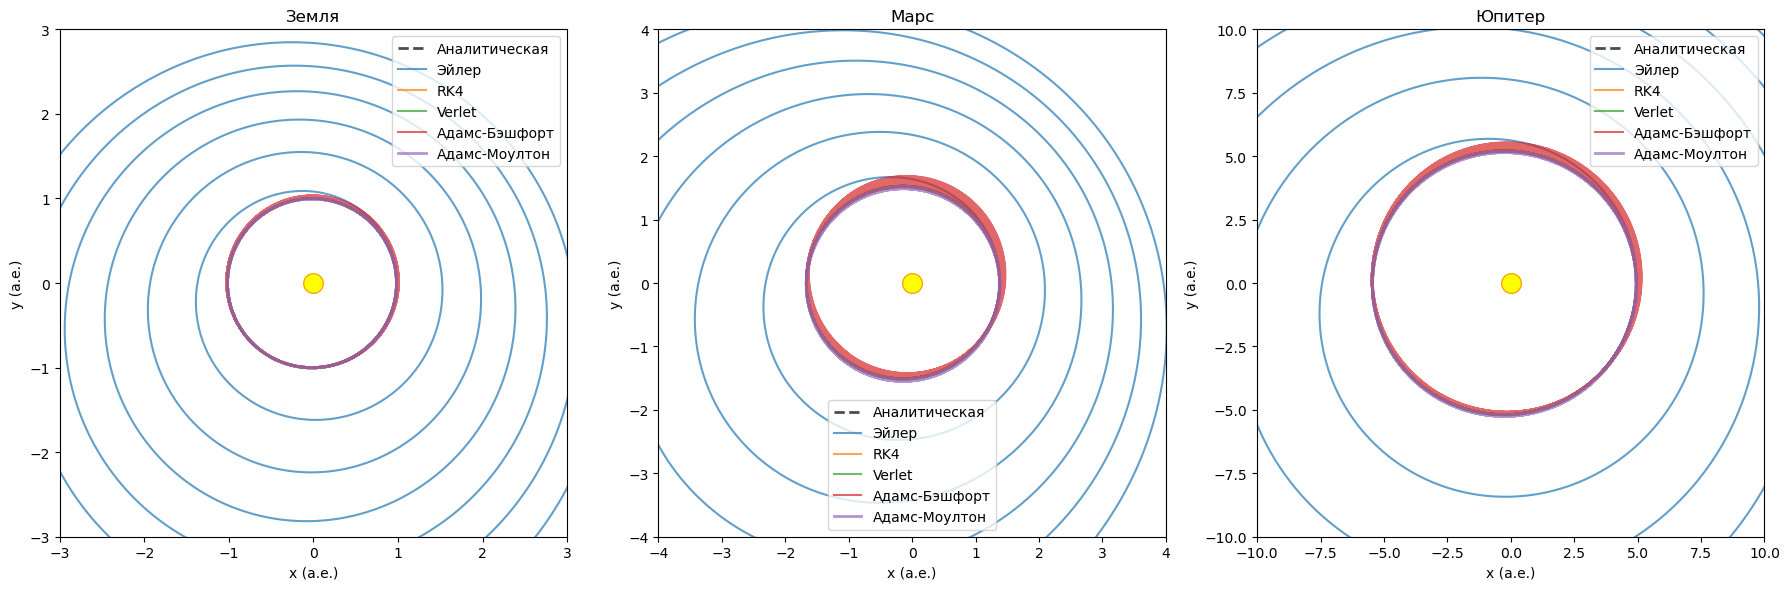

In [25]:
def timer(T, N, n):
    t_begin = 0
    t_end = T * n
    time = np.linspace(t_begin, t_end, N+1)
    dt = time[1]-time[0]
    return time, dt

def calc_orbit(a, e, T, N):
    x0, y0, vx0, vy0 = init_cond(a, e, T)
    x_an, y_an = analytic_solution(a, e)
    n = 25
    time, dt = timer(T, N, n)

    # Метод Эйлера
    s_Euler = np.zeros((N + 1, 4), dtype=np.float32)
    s_Euler[0] = np.array([x0, y0, vx0, vy0])
    
    # Метод RK4
    s_RK4 = np.zeros((N + 1, 4), dtype=np.float32)
    s_RK4[0] = np.array([x0, y0, vx0, vy0])

    for i in range(1, N + 1):
        s_Euler[i] = explicit_euler_step(s_Euler[i - 1], dt, a, T)
        s_RK4[i] = rk4_step(s_RK4[i - 1], dt, a, T)

    x_Euler = s_Euler[:, 0]
    y_Euler = s_Euler[:, 1]

    x_RK4 = s_RK4[:, 0]
    y_RK4 = s_RK4[:, 1]
    
    # Метод Верлета
    x_Verlet, y_Verlet, _, _ = verlet_integration(x0, y0, vx0, vy0, dt, N, a, T)
    
    # Метод Адамса-Бэшфорта
    x_AdamsB, y_AdamsB, _, _ = adams_bashforth(x0, y0, vx0, vy0, dt, N+1, a, T)
    
    # Метод Адамса-Моултона
    x_AdamsM, y_AdamsM, _, _ = adams_moulton(x0, y0, vx0, vy0, dt, N+1, a, T)
    
    return x_an, y_an, x_Euler, y_Euler, x_RK4, y_RK4, x_Verlet, y_Verlet, x_AdamsB, y_AdamsB, x_AdamsM, y_AdamsM

def draw_orbit():
    N = 3000 
    
    earth_results = calc_orbit(a_Earth, e_Earth, T_Earth, N)
    mars_results = calc_orbit(a_Mars, e_Mars, T_Mars, N)
    jupiter_results = calc_orbit(a_Jupiter, e_Jupiter, T_Jupiter, N)

    (x_an_E, y_an_E, x_Euler_E, y_Euler_E, x_RK4_E, y_RK4_E, 
     x_Verlet_E, y_Verlet_E, x_AdamsB_E, y_AdamsB_E, x_AdamsM_E, y_AdamsM_E) = earth_results
    
    (x_an_M, y_an_M, x_Euler_M, y_Euler_M, x_RK4_M, y_RK4_M, 
     x_Verlet_M, y_Verlet_M, x_AdamsB_M, y_AdamsB_M, x_AdamsM_M, y_AdamsM_M) = mars_results
    
    (x_an_J, y_an_J, x_Euler_J, y_Euler_J, x_RK4_J, y_RK4_J, 
     x_Verlet_J, y_Verlet_J, x_AdamsB_J, y_AdamsB_J, x_AdamsM_J, y_AdamsM_J) = jupiter_results
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Земля
    axes[0].plot(x_an_E, y_an_E, 'k--', label='Аналитическая', linewidth=2, alpha=0.7)
    axes[0].plot(x_Euler_E, y_Euler_E, label='Эйлер', alpha=0.7)
    axes[0].plot(x_RK4_E, y_RK4_E, label='RK4', alpha=0.7)
    axes[0].plot(x_Verlet_E, y_Verlet_E, label='Verlet', alpha=0.7)
    axes[0].plot(x_AdamsB_E, y_AdamsB_E, label='Адамс-Бэшфорт', alpha=0.7)
    axes[0].plot(x_AdamsM_E, y_AdamsM_E, label='Адамс-Моултон', alpha=0.7, linewidth=2)
    axes[0].scatter([0], [0], c='yellow', s=200, edgecolors='orange', zorder=5)
    axes[0].set_xlabel('x (а.е.)')
    axes[0].set_ylabel('y (а.е.)')
    axes[0].set_title('Земля')
    axes[0].legend()
    axes[0].set_aspect('equal')
    axes[0].set_xlim(-3, 3)
    axes[0].set_ylim(-3, 3)
    
    # Марс
    axes[1].plot(x_an_M, y_an_M, 'k--', label='Аналитическая', linewidth=2, alpha=0.7)
    axes[1].plot(x_Euler_M, y_Euler_M, label='Эйлер', alpha=0.7)
    axes[1].plot(x_RK4_M, y_RK4_M, label='RK4', alpha=0.7)
    axes[1].plot(x_Verlet_M, y_Verlet_M, label='Verlet', alpha=0.7)
    axes[1].plot(x_AdamsB_M, y_AdamsB_M, label='Адамс-Бэшфорт', alpha=0.7)
    axes[1].plot(x_AdamsM_M, y_AdamsM_M, label='Адамс-Моултон', alpha=0.7, linewidth=2)
    axes[1].scatter([0], [0], c='yellow', s=200, edgecolors='orange', zorder=5)
    axes[1].set_xlabel('x (а.е.)')
    axes[1].set_ylabel('y (а.е.)')
    axes[1].set_title('Марс')
    axes[1].legend()
    axes[1].set_aspect('equal')
    axes[1].set_xlim(-4, 4)
    axes[1].set_ylim(-4, 4)
    
    # Юпитер
    axes[2].plot(x_an_J, y_an_J, 'k--', label='Аналитическая', linewidth=2, alpha=0.7)
    axes[2].plot(x_Euler_J, y_Euler_J, label='Эйлер', alpha=0.7)
    axes[2].plot(x_RK4_J, y_RK4_J, label='RK4', alpha=0.7)
    axes[2].plot(x_Verlet_J, y_Verlet_J, label='Verlet', alpha=0.7)
    axes[2].plot(x_AdamsB_J, y_AdamsB_J, label='Адамс-Бэшфорт', alpha=0.7)
    axes[2].plot(x_AdamsM_J, y_AdamsM_J, label='Адамс-Моултон', alpha=0.7, linewidth=2)
    axes[2].scatter([0], [0], c='yellow', s=200, edgecolors='orange', zorder=5)
    axes[2].set_xlabel('x (а.е.)')
    axes[2].set_ylabel('y (а.е.)')
    axes[2].set_title('Юпитер')
    axes[2].legend()
    axes[2].legend(loc='upper right', frameon=True, fontsize=10)
    axes[2].set_aspect('equal')
    axes[2].set_xlim(-10, 10)
    axes[2].set_ylim(-10, 10)
    
    plt.tight_layout()
    plt.show()

# Запуск визуализации
draw_orbit()

**6. Проверка долгосрочного сохранения энергии и углового момента**

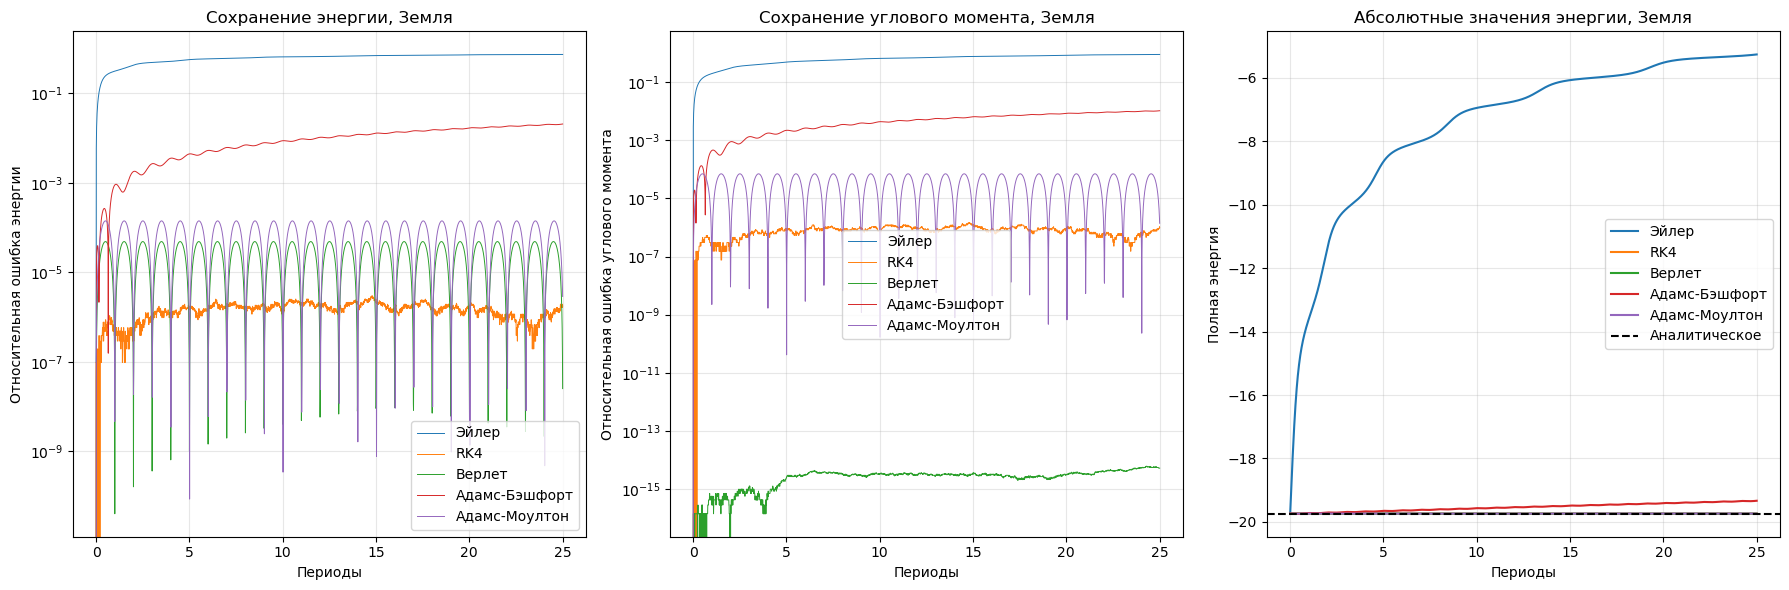

In [16]:
def energy_and_momentum(x, y, vx, vy, a, T):
    r = np.sqrt(x**2 + y**2)
    v_square = vx**2 + vy**2 # орбитальная скорость в квадрате
    kinetic_energy = 0.5 * v_square
    potential_energy = - GM(a, T) / r
    total_energy = kinetic_energy + potential_energy
    angular_momentum = x * vy - y * vx
    return total_energy, angular_momentum 

def calculate_energy_and_momentum(a, e, T, N):
    x0, y0, vx0, vy0 = init_cond(a, e, T)
    n = 25
    time, dt = timer(T, N, n)

    s_Euler = np.zeros((N + 1, 4), dtype=np.float32)
    s_Euler[0] = np.array([x0, y0, vx0, vy0])
    
    s_RK4 = np.zeros((N + 1, 4), dtype=np.float32)
    s_RK4[0] = np.array([x0, y0, vx0, vy0])

    for i in range(1, N + 1):
        s_Euler[i] = explicit_euler_step(s_Euler[i - 1], dt, a, T)
        s_RK4[i] = rk4_step(s_RK4[i - 1], dt, a, T)

    x_Euler = s_Euler[:, 0]
    y_Euler = s_Euler[:, 1]
    vx_Euler = s_Euler[:, 2]
    vy_Euler = s_Euler[:, 3]
    
    x_RK4 = s_RK4[:, 0]
    y_RK4 = s_RK4[:, 1]
    vx_RK4 = s_RK4[:, 2]
    vy_RK4 = s_RK4[:, 3]
    
    x_Verlet, y_Verlet, vx_Verlet, vy_Verlet = verlet_integration(x0, y0, vx0, vy0, dt, N, a, T)
    x_AdamsB, y_AdamsB, vx_AdamsB, vy_AdamsB = adams_bashforth(x0, y0, vx0, vy0, dt, N+1, a, T)
    x_AdamsM, y_AdamsM, vx_AdamsM, vy_AdamsM = adams_moulton(x0, y0, vx0, vy0, dt, N+1, a, T)

    E_an, L_an = 0.5 * (vx0**2 + vy0**2) - GM(a, T) / x0, x0 * vy0 - y0 * vx0
    E_Euler, L_Euler = energy_and_momentum(x_Euler, y_Euler, vx_Euler, vy_Euler, a, T)
    E_RK4, L_RK4 = energy_and_momentum(x_RK4, y_RK4, vx_RK4, vy_RK4, a, T)
    E_Verlet, L_Verlet = energy_and_momentum(x_Verlet, y_Verlet, vx_Verlet, vy_Verlet, a, T)
    E_AdamsB, L_AdamsB = energy_and_momentum(x_AdamsB, y_AdamsB, vx_AdamsB, vy_AdamsB, a, T)
    E_AdamsM, L_AdamsM = energy_and_momentum(x_AdamsM, y_AdamsM, vx_AdamsM, vy_AdamsM, a, T)
    return E_an, L_an, E_Euler, L_Euler, E_RK4, L_RK4, E_Verlet, L_Verlet, E_AdamsB, L_AdamsB, E_AdamsM, L_AdamsM, time, dt

def check_long_term_conservation(a, e, T, N, name):
    
    E_an, L_an, E_Euler, L_Euler, E_RK4, L_RK4, E_Verlet, L_Verlet, E_AdamsB, L_AdamsB, E_AdamsM, L_AdamsM, time, dt = calculate_energy_and_momentum(a, e, T, N)
    periods = time / T
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Вычисление относительной ошибки энергии
    rel_error_E_Euler = np.abs((E_Euler - E_an) / E_an)
    rel_error_E_RK4 = np.abs((E_RK4 - E_an) / E_an)
    rel_error_E_Verlet = np.abs((E_Verlet - E_an) / E_an)
    rel_error_E_AdamsB = np.abs((E_AdamsB - E_an) / E_an)
    rel_error_E_AdamsM = np.abs((E_AdamsM - E_an) / E_an)
    
    axes[0].plot(periods, rel_error_E_Euler, label='Эйлер', linewidth=0.7)
    axes[0].plot(periods, rel_error_E_RK4, label='RK4', linewidth=0.7)
    axes[0].plot(periods, rel_error_E_Verlet, label='Верлет', linewidth=0.7)
    axes[0].plot(periods, rel_error_E_AdamsB, label='Адамс-Бэшфорт', linewidth=0.7)
    axes[0].plot(periods, rel_error_E_AdamsM, label='Адамс-Моултон', linewidth=0.7)
    axes[0].set_xlabel('Периоды')
    axes[0].set_ylabel('Относительная ошибка энергии')
    axes[0].set_title(f'Сохранение энергии, {name}')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    # Вычисление относительной ошибки углового момента
    rel_error_L_Euler = np.abs((L_Euler - L_an) / L_an)
    rel_error_L_RK4 = np.abs((L_RK4 - L_an) / L_an)
    rel_error_L_Verlet = np.abs((L_Verlet - L_an) / L_an)
    rel_error_L_AdamsB = np.abs((L_AdamsB - L_an) / L_an)
    rel_error_L_AdamsM = np.abs((L_AdamsM - L_an) / L_an)
    
    axes[1].plot(periods, rel_error_L_Euler, label='Эйлер', linewidth=0.7)
    axes[1].plot(periods, rel_error_L_RK4, label='RK4', linewidth=0.7)
    axes[1].plot(periods, rel_error_L_Verlet, label='Верлет', linewidth=0.7)
    axes[1].plot(periods, rel_error_L_AdamsB, label='Адамс-Бэшфорт', linewidth=0.7)
    axes[1].plot(periods, rel_error_L_AdamsM, label='Адамс-Моултон', linewidth=0.7)
    axes[1].set_xlabel('Периоды')
    axes[1].set_ylabel('Относительная ошибка углового момента')
    axes[1].set_title(f'Сохранение углового момента, {name}')
    axes[1].legend()
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3)

    # Абсолютные значения энергии 
    axes[2].plot(periods, E_Euler, label='Эйлер', linewidth=1.5)
    axes[2].plot(periods, E_RK4, label='RK4', linewidth=1.5)
    axes[2].plot(periods, E_Verlet, label='Верлет', linewidth=1.5)
    axes[2].plot(periods, E_AdamsB, label='Адамс-Бэшфорт', linewidth=1.5)
    axes[2].plot(periods, E_AdamsM, label='Адамс-Моултон', linewidth=1.5)
    axes[2].axhline(y=E_an, color='black', linestyle='--', label='Аналитическое')
    axes[2].set_xlabel('Периоды')
    axes[2].set_ylabel('Полная энергия')
    axes[2].set_title(f'Абсолютные значения энергии, {name}')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
check_long_term_conservation(a_Earth, e_Earth, T_Earth, N=3000, name = "Земля")

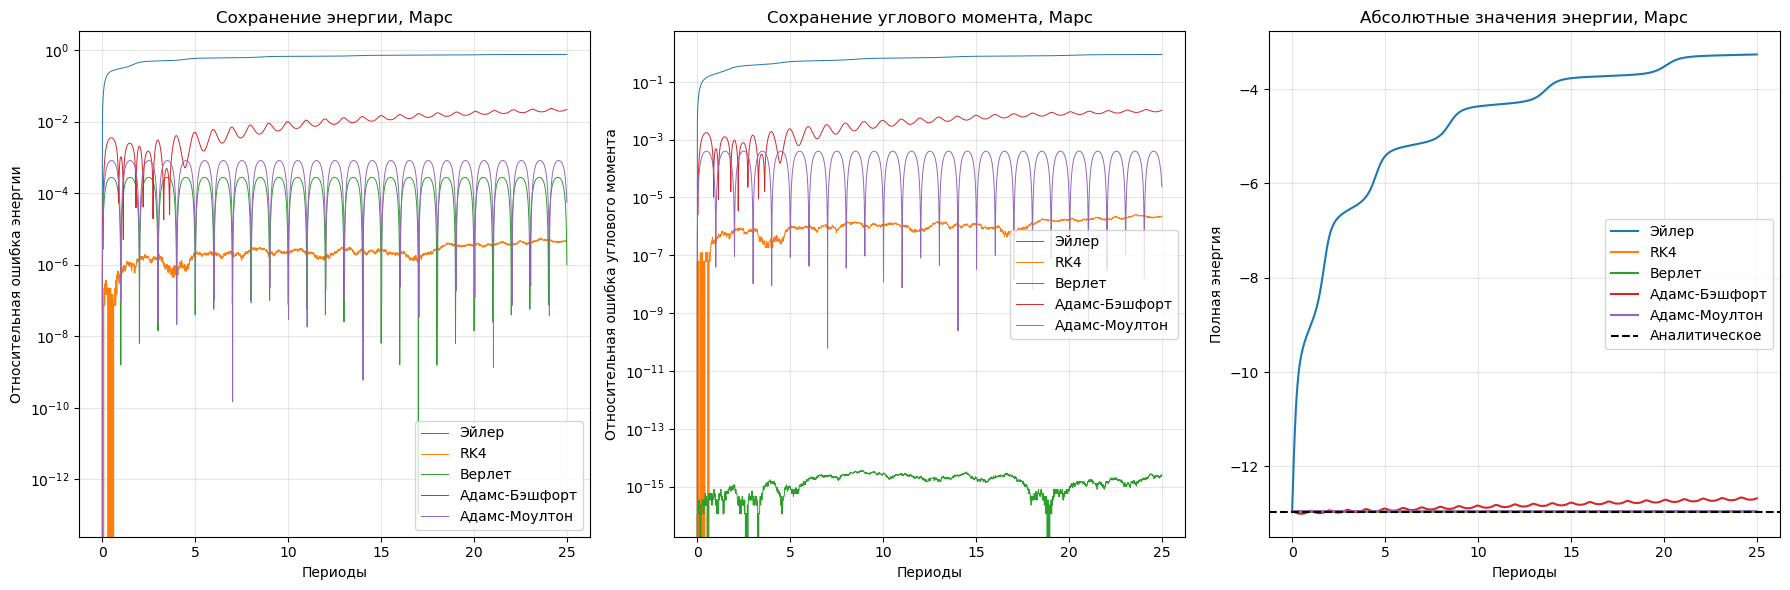

In [17]:
check_long_term_conservation(a_Mars, e_Mars, T_Mars, N=3000, name = "Марс")

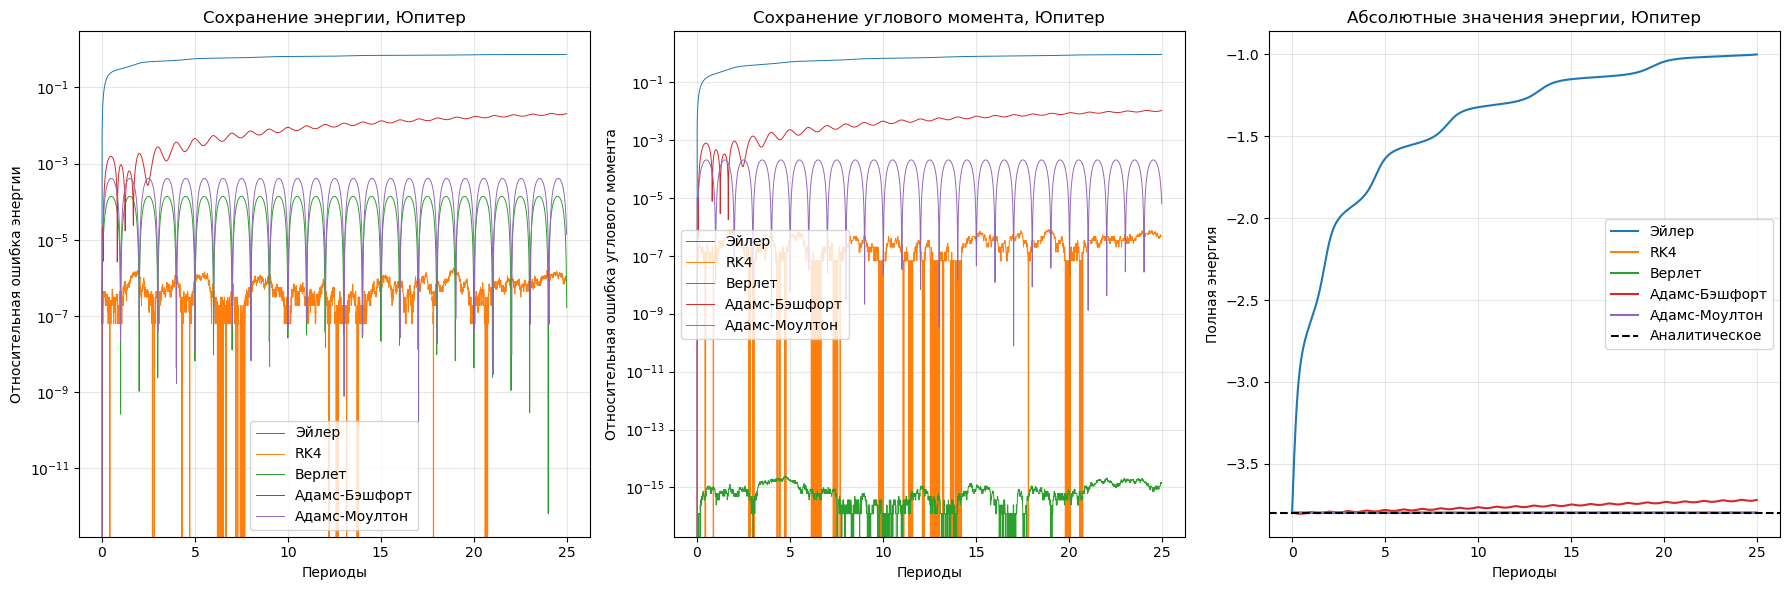

In [18]:
check_long_term_conservation(a_Jupiter, e_Jupiter, T_Jupiter, N=3000, name = "Юпитер")

**7. Сравнение стабильности с RK4/Эйлером на многих оборотах**

In [19]:
def calculate_deviation(x_num, y_num, x_an, y_an):
    return np.sqrt((x_num - x_an)**2 + (y_num - y_an)**2)
    
def compare_trajectory_deviation(a, e, T, N, name):
    x0, y0, vx0, vy0 = init_cond(a, e, T)
    n_periods = 25
    time, dt = timer(T, N, n_periods)
    
    s_Euler = np.zeros((N + 1, 4), dtype=np.float32)
    s_Euler[0] = np.array([x0, y0, vx0, vy0])
    s_RK4 = np.zeros((N + 1, 4), dtype=np.float32)
    s_RK4[0] = np.array([x0, y0, vx0, vy0])

    for i in range(1, N + 1):
        s_Euler[i] = explicit_euler_step(s_Euler[i - 1], dt, a, T)
        s_RK4[i] = rk4_step(s_RK4[i - 1], dt, a, T)

    x_Euler, y_Euler = s_Euler[:, 0], s_Euler[:, 1]
    x_RK4, y_RK4 = s_RK4[:, 0], s_RK4[:, 1]
    
    x_Verlet, y_Verlet, vx_Verlet, vy_Verlet = verlet_integration(x0, y0, vx0, vy0, dt, N, a, T)
    x_AdamsB, y_AdamsB, vx_AdamsB, vy_AdamsB = adams_bashforth(x0, y0, vx0, vy0, dt, N+1, a, T)
    x_AdamsM, y_AdamsM, vx_AdamsM, vy_AdamsM = adams_moulton(x0, y0, vx0, vy0, dt, N+1, a, T)

    theta_analytic = 2 * np.pi * time / T 
    r_analytic = a * (1 - e**2) / (1 + e * np.cos(theta_analytic))
    x_analytic = r_analytic * np.cos(theta_analytic)
    y_analytic = r_analytic * np.sin(theta_analytic)
    
    deviation_Euler = calculate_deviation(x_Euler, y_Euler, x_analytic, y_analytic)
    deviation_RK4 = calculate_deviation(x_RK4, y_RK4, x_analytic, y_analytic)
    deviation_Verlet = calculate_deviation(x_Verlet, y_Verlet, x_analytic, y_analytic)
    deviation_AdamsB = calculate_deviation(x_AdamsB, y_AdamsB, x_analytic, y_analytic)
    deviation_AdamsM = calculate_deviation(x_AdamsM, y_AdamsM, x_analytic, y_analytic)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].plot(time/T, deviation_Euler, label='Эйлер', linewidth=0.5)
    axes[0].plot(time/T, deviation_RK4, label='RK4', linewidth=0.5)
    axes[0].plot(time/T, deviation_Verlet, label='Верлет', linewidth=0.5)
    axes[0].plot(time/T, deviation_AdamsB, label='Адамс-Бэшфорт', linewidth=0.5)
    axes[0].plot(time/T, deviation_AdamsM, label='Адамс-Моултон', linewidth=0.5)
    axes[0].set_xlabel('Периоды')
    axes[0].set_ylabel('Отклонение траектории (а.е.)')
    axes[0].set_title(f'Отклонение от аналитической траектории, {name}')
    axes[0].legend()
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    methods = ['Эйлер', 'RK4', 'Верлет', 'А-Б', 'А-М']
    max_deviations = [np.max(deviation_Euler), np.max(deviation_RK4), np.max(deviation_Verlet), np.max(deviation_AdamsB), np.max(deviation_AdamsM)]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    bars = axes[1].bar(methods, max_deviations, color=colors, alpha=0.7)
    axes[1].set_ylabel('Максимальное отклонение (а.е.)')
    axes[1].set_title('Максимальное отклонение траектории')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, value in zip(bars, max_deviations):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, f'{value:.2e}', ha='center', va='bottom', fontsize=10)
    
    rel_deviation_Euler = deviation_Euler / a * 100
    rel_deviation_RK4 = deviation_RK4 / a * 100
    rel_deviation_Verlet = deviation_Verlet / a * 100
    rel_deviation_AdamsB = deviation_AdamsB / a * 100
    rel_deviation_AdamsM = deviation_AdamsM / a * 100
    
    axes[2].plot(time/T, rel_deviation_Euler, label='Эйлер', linewidth=0.5)
    axes[2].plot(time/T, rel_deviation_RK4, label='RK4', linewidth=0.5)
    axes[2].plot(time/T, rel_deviation_Verlet, label='Верлет', linewidth=0.5)
    axes[2].plot(time/T, rel_deviation_AdamsB, label='Адамс-Бэшфорт', linewidth=0.5)
    axes[2].plot(time/T, rel_deviation_AdamsM, label='Адамс-Моултон', linewidth=0.5)
    axes[2].set_xlabel('Периоды')
    axes[2].set_ylabel('Относительное отклонение (% от a)')
    axes[2].set_title('Относительное отклонение траектории')
    axes[2].legend()
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

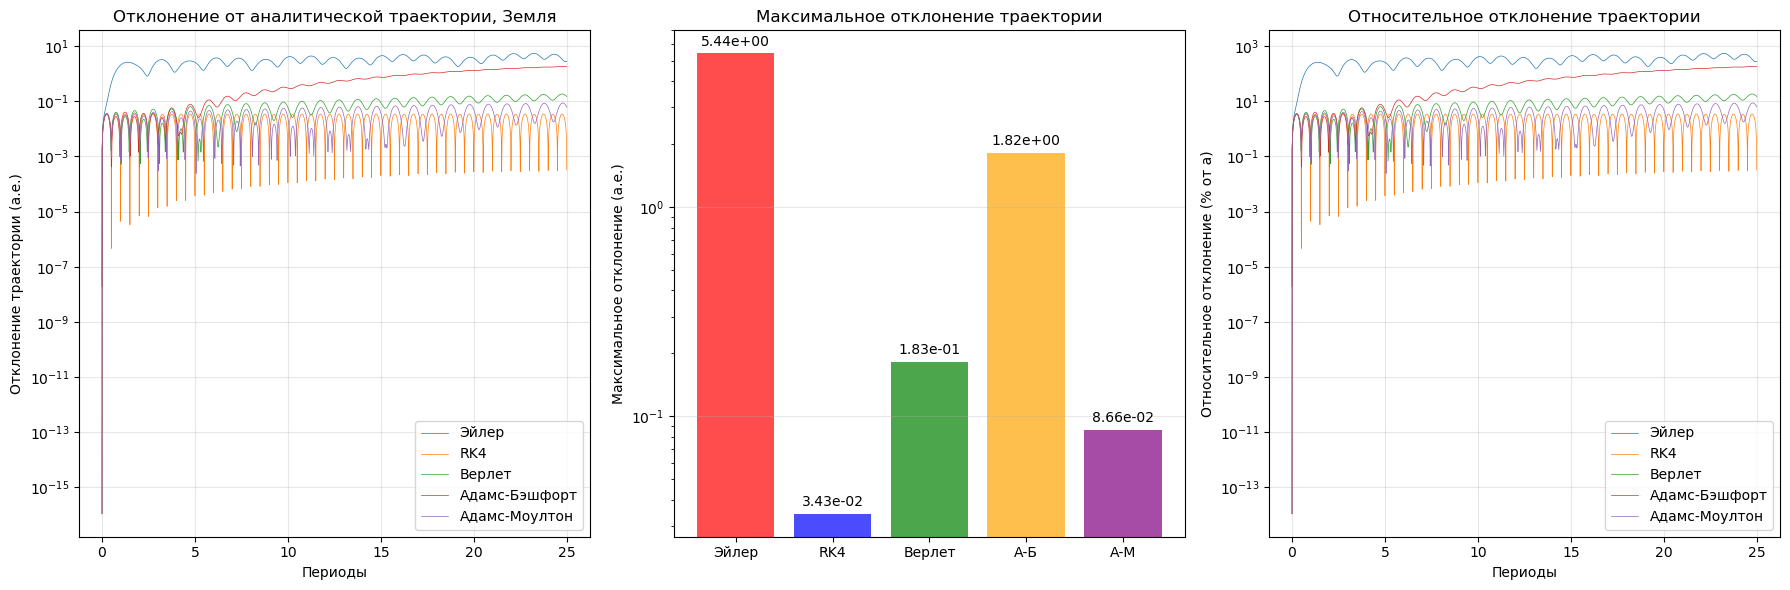

In [20]:
compare_trajectory_deviation(a_Earth, e_Earth, T_Earth, N=3000, name = "Земля")

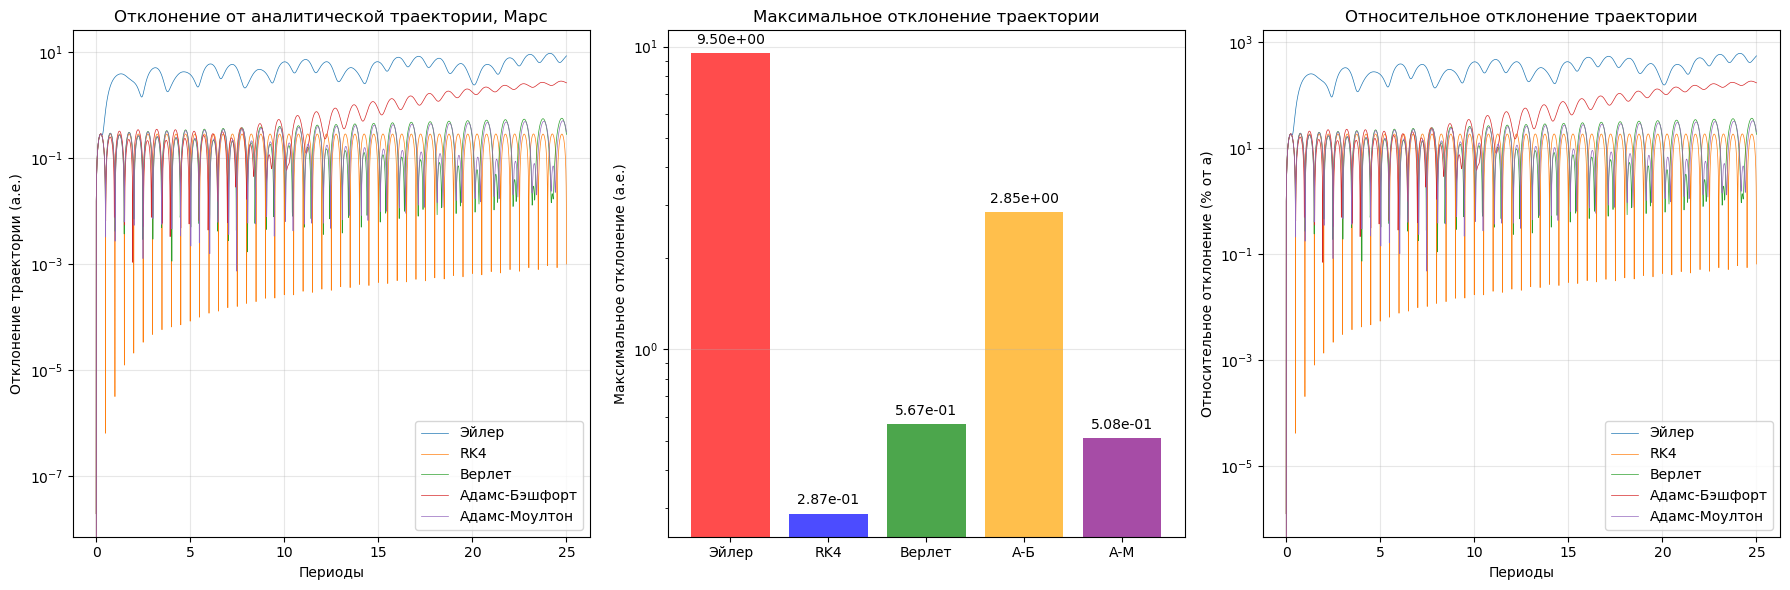

In [21]:
compare_trajectory_deviation(a_Mars, e_Mars, T_Mars, N=3000, name = "Марс")

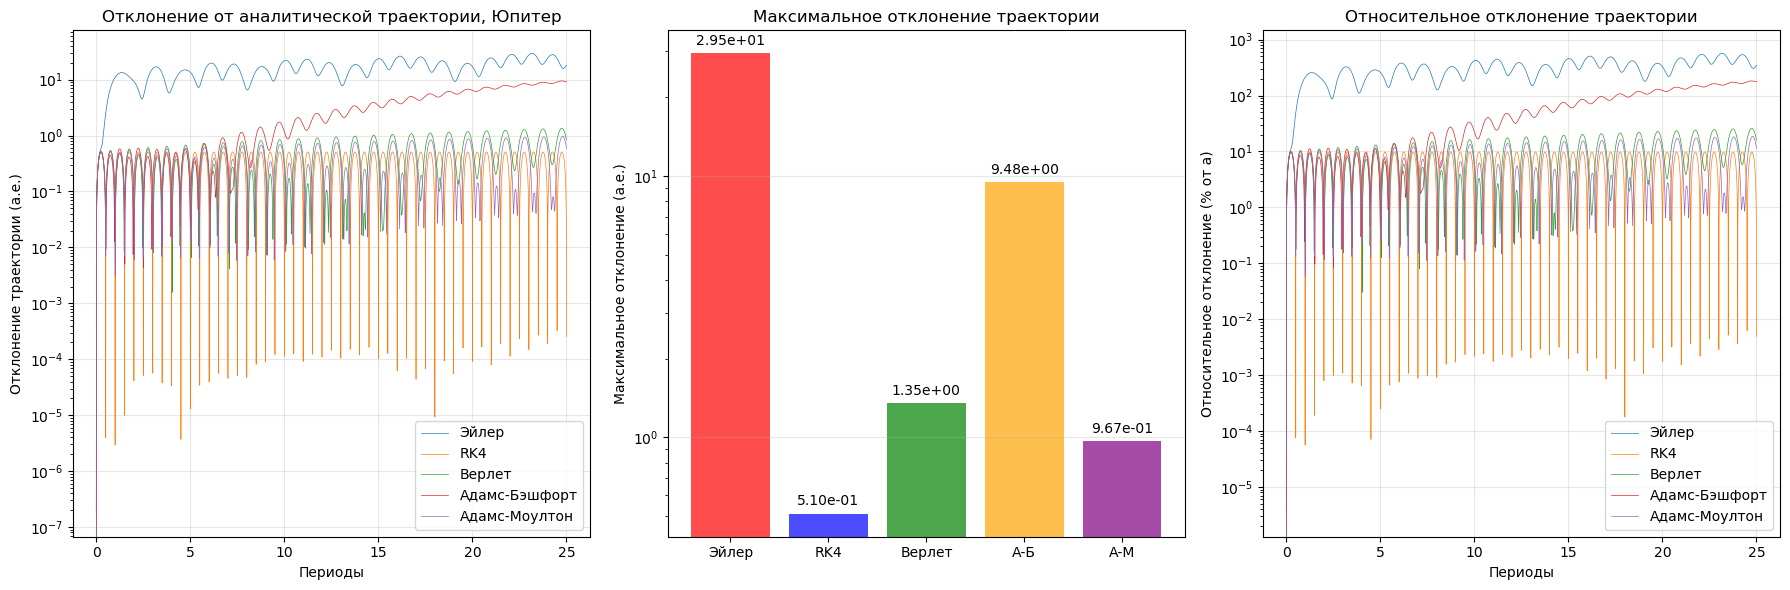

In [22]:
compare_trajectory_deviation(a_Jupiter, e_Jupiter, T_Jupiter, N=3000, name = "Юпитер")

**8. Результаты и их обсуждение**

*8.1 Верификация численных методов*

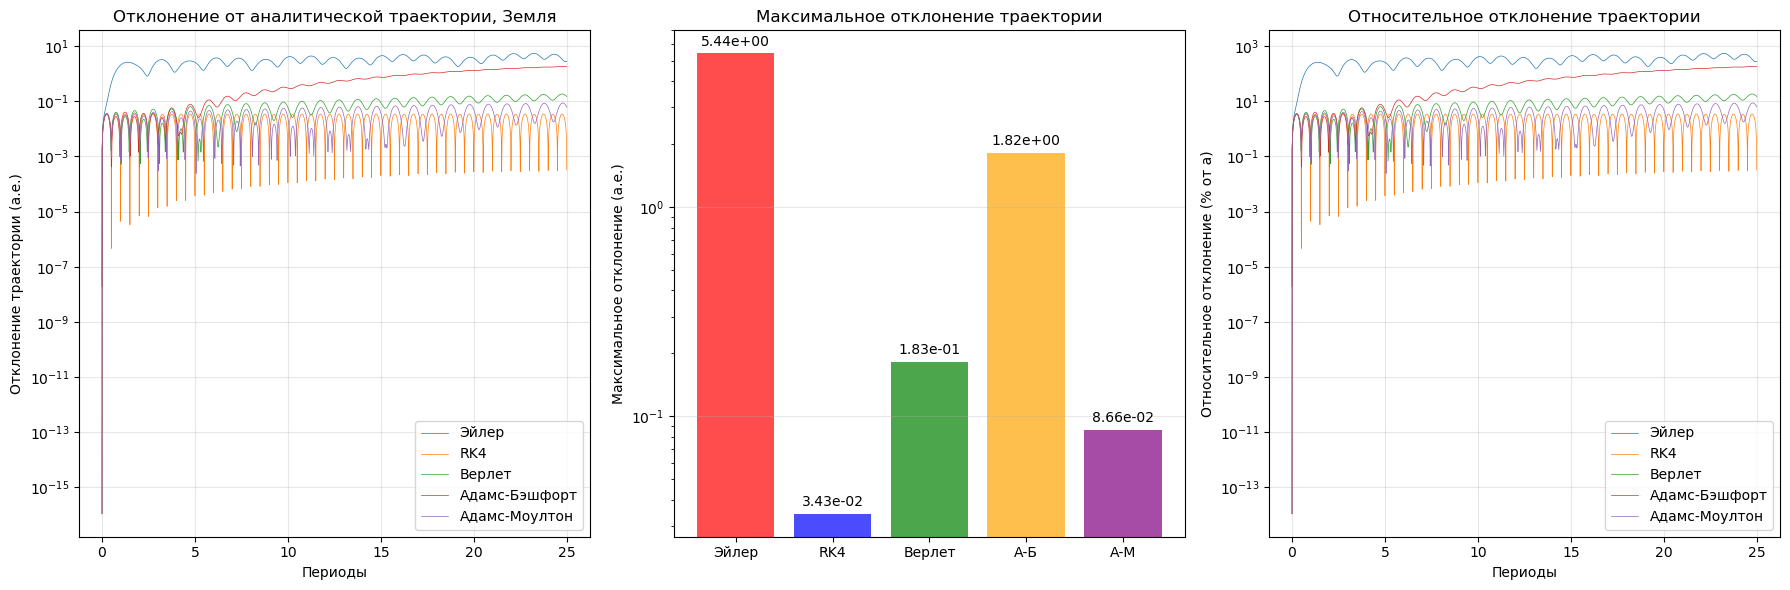

In [26]:
compare_trajectory_deviation(a_Earth, e_Earth, T_Earth, N=3000, name = "Земля")

Для проверки корректности реализации всех численных методов было выполнено сравнение с аналитическим решением задачи двух тел. На рисунке представлены траектории движения Земли, полученные различными методами, в сравнении с эллиптической орбитой, рассчитанной по уравнению Кеплера.

Все методы, за исключением явного метода Эйлера и метода Адамса-Бэшфорта, удовлетворительно воспроизводят замкнутую эллиптическую траекторию. Наибольшее визуальное соответствие аналитическому решению демонстрируют метод Рунге-Кутты 4-го порядка. Метод Эйлера проявляет значительное отклонение орбиты, что связано с накоплением ошибки интегрирования, характерным для методов первого порядка точности.

*8.2 Сравнение методов по точности и сохранению инвариантов*

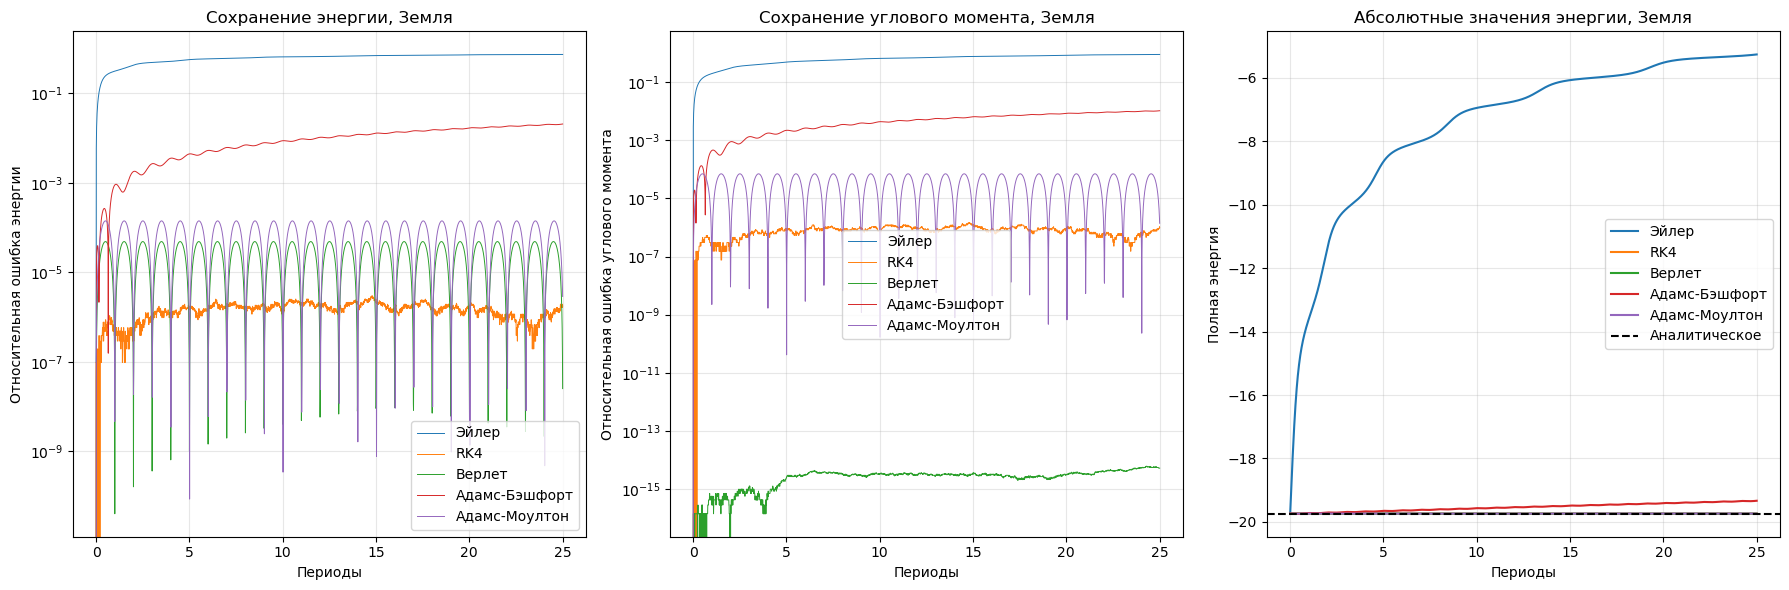

In [27]:
check_long_term_conservation(a_Earth, e_Earth, T_Earth, N=3000, name = "Земля")

На рисунке представлен график относительной ошибки полной энергии для орбиты Земли. Метод Эйлера показывает экспоненциальны рост ошибки, что делает его непригодным для долговременного моделирования. Метод Адамса-Бэшфорта демонстрирует меньшую, но также растущую ошибку.

Сравненим методы Рунге-Кутты и Верлета. На интервале моделирования в 25 периодов метод РК4 показывает меньшую относительную ошибку энергии. Однако у РК4 наблюдается монотонный дрейф, в то время как у алгоритма Верлета ошибка энергии совершает ограниченные колебания около среднего значения. Это является прямым следствием симплектичности алгоритма Верлета, который сохраняет фазовый объем гамильтоновой системы.

Анализ сохранения углового момента подтверждает выводы, сделанные для энергии. Методы Рунге-Кутты и Верлета обеспечивают высокую стабильность момента импульса, в то время при использовании методов Эйлера и Адамса наблюдается рост ошибки..

**9. Заключение**

В результате работы мы сравнили пять численных методов для расчета орбит планет. Оказалось, что: \
• Метод Эйлера слишком неточный для таких задач \
• Метод Рунге-Кутты лучше всего подходит для точных расчетов на несколько оборотов вокруг Солнца \
• Метод Верлета надежнее для очень долгих расчетов - он сохраняет энергию системы \
• Методы Адамса работают средне - точнее Эйлера, но хуже Рунге-Кутты 

Какие перспективы развития работы: расширение до задачи N тел (моделирование взаимодействия нескольких планет или спутников), учет дополнительных физических факторов (например, несферичность небесных тел).

**Список использованной литературы**

[1] Птолемей К. Альмагест. Около 140 г. н.э. \
[2] Коперник Н. О вращении небесных сфер. 1543 \
[3] Кеплер И. Новая астрономия. 1609 \
[4] Ньютон И. Математические начала натуральной философии. 1687 \
[5] Эйлер Л. Интегральное исчисление. Том II. 1768 \
[6] Runge C. Über die numerische Auflösung von Differentialgleichungen // Matematische Annalen, 39, 1895. - P. 443–447. \
[7] Cutta W. Beitrag zur näherungsweisen Integration totaler Differentialgleichungen // Zeitschrift für Mathematik und Physik, 46, 1901. - P. 435-453. \
[8] Bashforth F. An Attempt to test the Theories of Capillary Action. 1883 \
[9] Verlet L. Computer "Experiments" on Classical Fluids // Physical Review. 1967 \